In [15]:
import pandas as pd

# 데이터 로드
residual1 = pd.read_csv('data/residual_features_frac_0.1.csv')
residual2 = pd.read_csv('data/residual_features_frac_0.2.csv')
residual3 = pd.read_csv('data/residual_features_frac_0.3.csv')
residual4 = pd.read_csv('data/residual_features_frac_0.4.csv')
residual5 = pd.read_csv('data/residual_features_frac_0.5.csv')
residual6 = pd.read_csv('data/residual_features_frac_0.6.csv')

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

from pct import PCTChart


In [29]:
def run_pct_analysis(df, title="PCT analysis", alpha=0.05, plot=True):
    # --------------------------------------------------
    # 1) Feature / target
    # --------------------------------------------------
    df = df.copy()

    feature_cols = [c for c in df.columns if c not in ["sample_idx", "status"]]
    X = df[feature_cols].copy()
    y = df["status"].copy()

    X = X.apply(pd.to_numeric, errors="coerce")

    # --------------------------------------------------
    # 2) Split
    # --------------------------------------------------
    train_mask = df["sample_idx"].between(0, 199)
    normal_mask = df["sample_idx"].between(200, 319)
    damaged_mask = df["sample_idx"].between(320, 399)

    X_train = X.loc[train_mask].to_numpy(dtype=float)
    X_normal = X.loc[normal_mask].to_numpy(dtype=float)
    X_damaged = X.loc[damaged_mask].to_numpy(dtype=float)

    y_normal = y.loc[normal_mask].to_numpy()
    y_damaged = y.loc[damaged_mask].to_numpy()

    # --------------------------------------------------
    # 3) Fit
    # --------------------------------------------------
    pct = PCTChart(alpha=alpha)
    pct.fit(X_train)

    # --------------------------------------------------
    # 4) Score
    # --------------------------------------------------
    res_train = pct.score_samples(X_train)
    res_normal = pct.score_samples(X_normal)
    res_damaged = pct.score_samples(X_damaged)

    normal_alarm = np.asarray(res_normal.alarms)
    damaged_alarm = np.asarray(res_damaged.alarms)

    far = normal_alarm.mean()
    detection_rate = damaged_alarm.mean()

    # --------------------------------------------------
    # 5) 대표 분포 파라미터
    # --------------------------------------------------
    q_train = np.asarray(res_train.q_values, dtype=float)
    q_normal = np.asarray(res_normal.q_values, dtype=float)
    q_damaged = np.asarray(res_damaged.q_values, dtype=float)

    df_param = float(res_train.dfs[0])
    scale_param = float(res_train.scales[0])
    ucl_param = float(res_train.ucls[0])

    # confusion-like summary
    tp = int(damaged_alarm.sum())
    fn = int((~damaged_alarm).sum())
    fp = int(normal_alarm.sum())
    tn = int((~normal_alarm).sum())

    # --------------------------------------------------
    # 6) Print summary
    # --------------------------------------------------
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(f"# train samples         : {len(X_train)}")
    print(f"# unseen normal samples : {len(X_normal)}")
    print(f"# damaged samples       : {len(X_damaged)}")
    print("-" * 80)
    print(f"False Alarm Rate : {far:.4f} ({fp}/{len(normal_alarm)})")
    print(f"Detection Rate   : {detection_rate:.4f} ({tp}/{len(damaged_alarm)})")
    print("-" * 80)
    print(f"Representative df    : {df_param:.6f}")
    print(f"Representative scale : {scale_param:.6f}")
    print(f"Representative UCL   : {ucl_param:.6f}")
    print("-" * 80)
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    # --------------------------------------------------
    # 7) Plot
    # --------------------------------------------------
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # (1) train histogram
        axes[0].hist(q_train, bins=20, alpha=0.7, edgecolor="black", density=True)
        axes[0].axvline(ucl_param, color="red", linestyle="--", label=f"UCL={ucl_param:.3f}")
        axes[0].set_title(f"{title}\nTrain Q* distribution")
        axes[0].set_xlabel("Q*")
        axes[0].set_ylabel("Density")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # (2) empirical vs theoretical
        x_grid = np.linspace(0, max(q_train.max(), ucl_param) * 1.2, 500)
        pdf_vals = chi2.pdf(x_grid / scale_param, df=df_param) / scale_param

        axes[1].hist(q_train, bins=20, density=True, alpha=0.6, edgecolor="black", label="Empirical")
        axes[1].plot(x_grid, pdf_vals, color="blue", linewidth=2, label="Scaled chi-square")
        axes[1].axvline(ucl_param, color="red", linestyle="--", label="UCL")
        axes[1].set_title(f"{title}\nEmpirical vs theoretical")
        axes[1].set_xlabel("Q*")
        axes[1].set_ylabel("Density")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        # (3) train / normal / damaged
        axes[2].hist(q_train, bins=20, alpha=0.4, density=True, label="Train")
        axes[2].hist(q_normal, bins=20, alpha=0.4, density=True, label="Normal")
        axes[2].hist(q_damaged, bins=20, alpha=0.4, density=True, label="Damaged")
        axes[2].axvline(ucl_param, color="red", linestyle="--", linewidth=2, label="UCL")
        axes[2].set_title(f"{title}\nQ* comparison")
        axes[2].set_xlabel("Q*")
        axes[2].set_ylabel("Density")
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------
    # 8) Return
    # --------------------------------------------------
    result_summary = pd.DataFrame({
        "title": [title],
        "n_train": [len(X_train)],
        "n_normal": [len(X_normal)],
        "n_damaged": [len(X_damaged)],
        "far": [far],
        "detection_rate": [detection_rate],
        "df_param": [df_param],
        "scale_param": [scale_param],
        "ucl_param": [ucl_param],
        "tn": [tn],
        "fp": [fp],
        "fn": [fn],
        "tp": [tp],
    })

    return {
        "pct": pct,
        "res_train": res_train,
        "res_normal": res_normal,
        "res_damaged": res_damaged,
        "summary": result_summary
    }


PCT result - frac=0.1
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
--------------------------------------------------------------------------------
False Alarm Rate : 0.0500 (6/120)
Detection Rate   : 1.0000 (80/80)
--------------------------------------------------------------------------------
Representative df    : 5.091301
Representative scale : 0.198625
Representative UCL   : 2.226909
--------------------------------------------------------------------------------
TN: 114
FP: 6
FN: 0
TP: 80


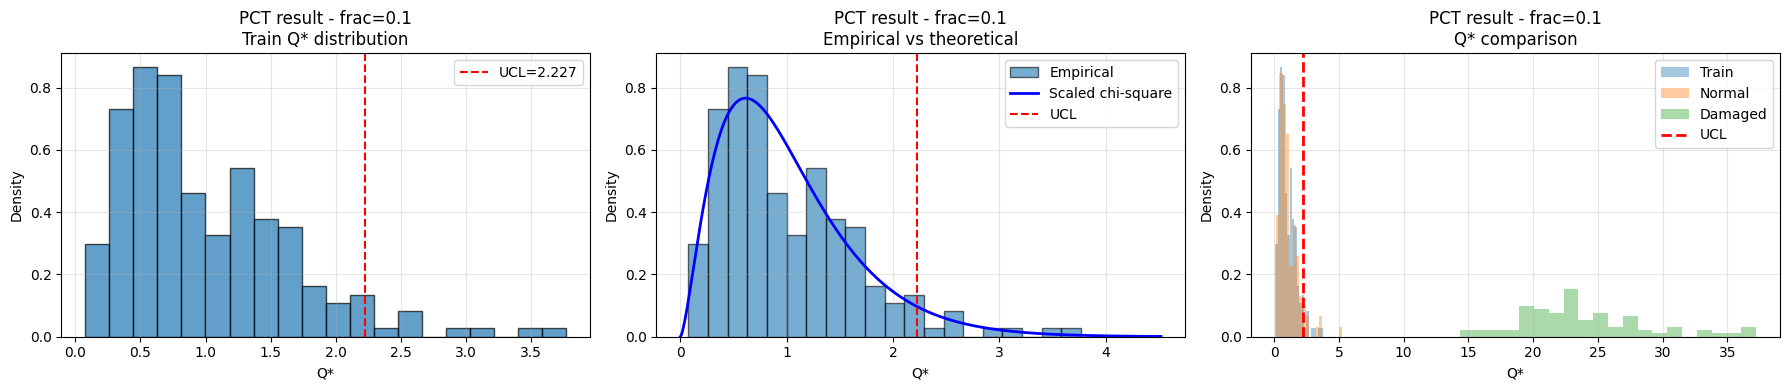

,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.1,200,120,80,0.05,1.0,5.091301,0.198625,2.226909,114,6,0,80


In [30]:
out1 = run_pct_analysis(residual1, title="PCT result - frac=0.1", alpha=0.05, plot=True)
out1["summary"]


PCT result - frac=0.2
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
--------------------------------------------------------------------------------
False Alarm Rate : 0.0833 (10/120)
Detection Rate   : 1.0000 (80/80)
--------------------------------------------------------------------------------
Representative df    : 5.615385
Representative scale : 0.180374
Representative UCL   : 2.166768
--------------------------------------------------------------------------------
TN: 110
FP: 10
FN: 0
TP: 80


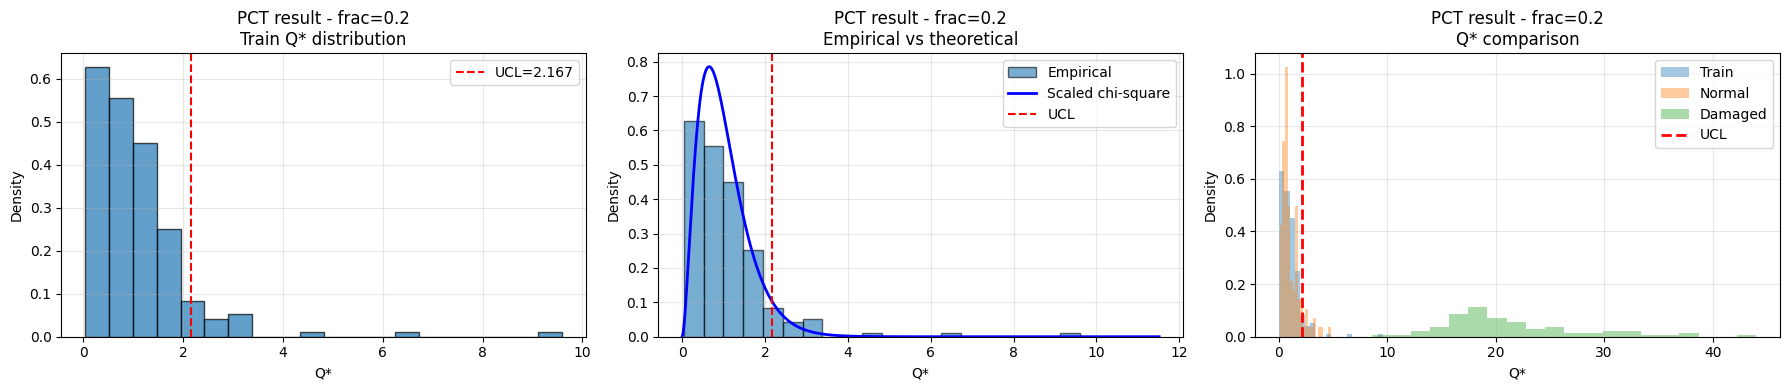

,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.2,200,120,80,0.083333,1.0,5.615385,0.180374,2.166768,110,10,0,80


In [31]:
out2 = run_pct_analysis(residual2, title="PCT result - frac=0.2", alpha=0.05, plot=True)
out2["summary"]


PCT result - frac=0.3
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
--------------------------------------------------------------------------------
False Alarm Rate : 0.0750 (9/120)
Detection Rate   : 1.0000 (80/80)
--------------------------------------------------------------------------------
Representative df    : 5.647454
Representative scale : 0.179679
Representative UCL   : 2.167144
--------------------------------------------------------------------------------
TN: 111
FP: 9
FN: 0
TP: 80


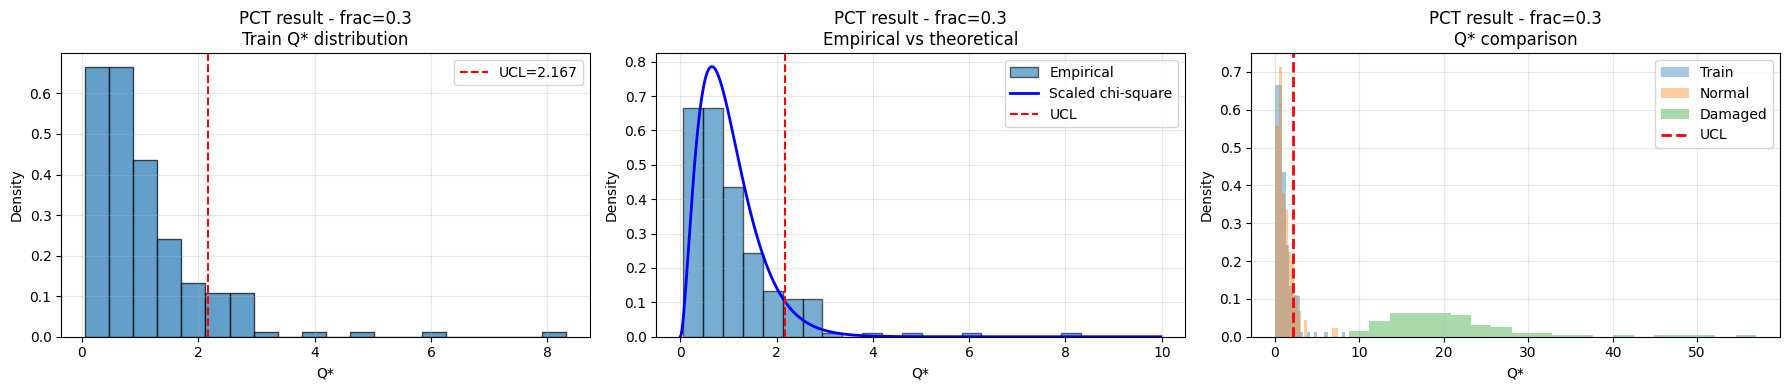

,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.3,200,120,80,0.075,1.0,5.647454,0.179679,2.167144,111,9,0,80


In [32]:
out3 = run_pct_analysis(residual3, title="PCT result - frac=0.3", alpha=0.05, plot=True)
out3["summary"]


PCT result - frac=0.4
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
--------------------------------------------------------------------------------
False Alarm Rate : 0.1083 (13/120)
Detection Rate   : 0.9625 (77/80)
--------------------------------------------------------------------------------
Representative df    : 4.553750
Representative scale : 0.223388
Representative UCL   : 2.317225
--------------------------------------------------------------------------------
TN: 107
FP: 13
FN: 3
TP: 77


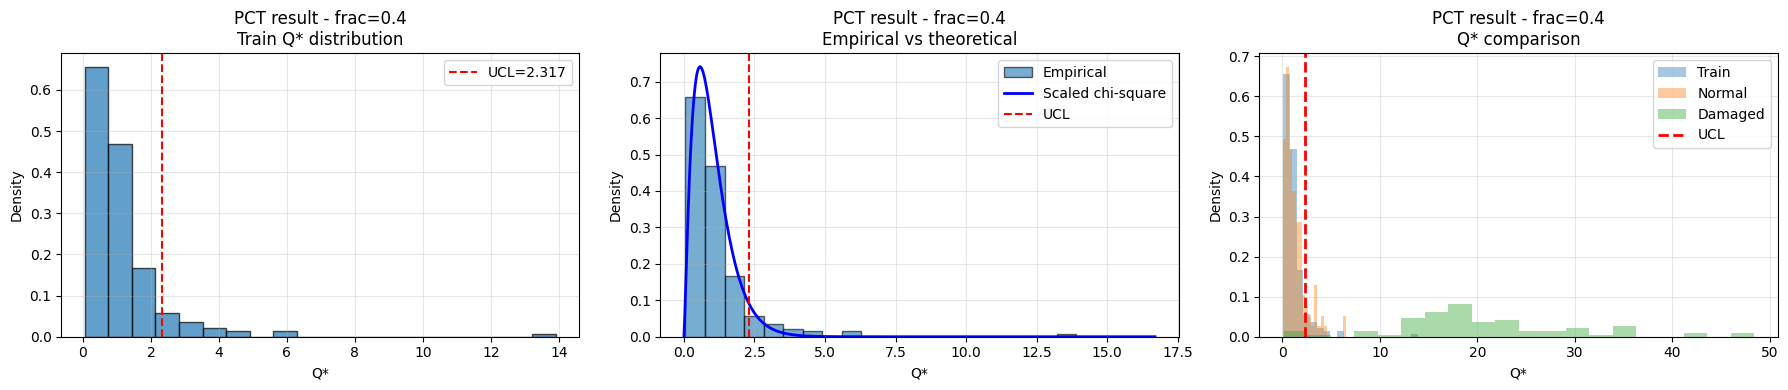

,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.4,200,120,80,0.108333,0.9625,4.55375,0.223388,2.317225,107,13,3,77


In [33]:
out4 = run_pct_analysis(residual4, title="PCT result - frac=0.4", alpha=0.05, plot=True)
out4["summary"]


PCT result - frac=0.5
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
--------------------------------------------------------------------------------
False Alarm Rate : 0.1333 (16/120)
Detection Rate   : 0.9375 (75/80)
--------------------------------------------------------------------------------
Representative df    : 4.042277
Representative scale : 0.252543
Representative UCL   : 2.413351
--------------------------------------------------------------------------------
TN: 104
FP: 16
FN: 5
TP: 75


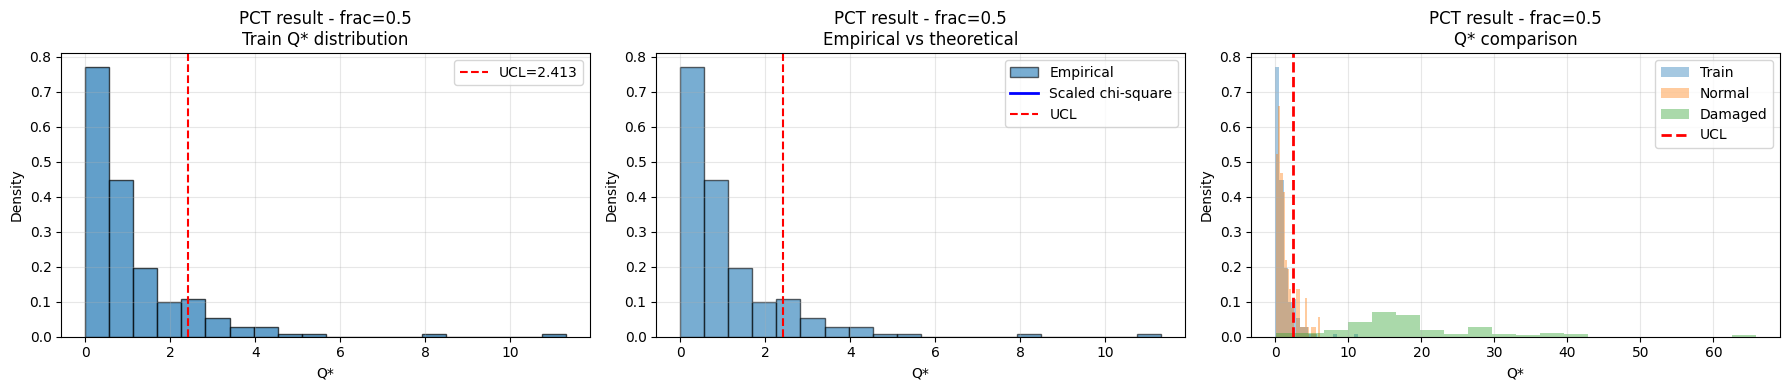

,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.5,200,120,80,0.133333,0.9375,4.042277,0.252543,2.413351,104,16,5,75


In [34]:
out5 = run_pct_analysis(residual5, title="PCT result - frac=0.5", alpha=0.05, plot=True)
out5["summary"]


PCT result - frac=0.6
# train samples         : 200
# unseen normal samples : 120
# damaged samples       : 80
--------------------------------------------------------------------------------
False Alarm Rate : 0.1167 (14/120)
Detection Rate   : 0.8875 (71/80)
--------------------------------------------------------------------------------
Representative df    : 2.600675
Representative scale : 0.394226
Representative UCL   : 2.802978
--------------------------------------------------------------------------------
TN: 106
FP: 14
FN: 9
TP: 71


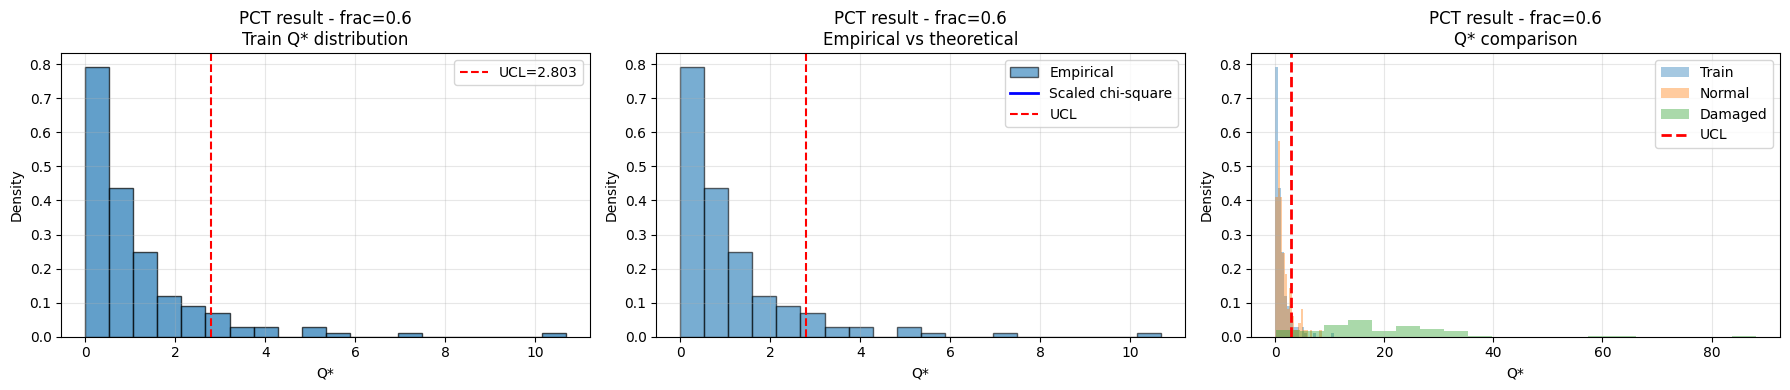

,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.6,200,120,80,0.116667,0.8875,2.600675,0.394226,2.802978,106,14,9,71


In [35]:
out6 = run_pct_analysis(residual6, title="PCT result - frac=0.6", alpha=0.05, plot=True)
out6["summary"]


In [36]:
summary_all = pd.concat([
    out1["summary"],
    out2["summary"],
    out3["summary"],
    out4["summary"],
    out5["summary"],
    out6["summary"],
], ignore_index=True)

summary_all


,title,n_train,n_normal,n_damaged,far,detection_rate,df_param,scale_param,ucl_param,tn,fp,fn,tp
0,PCT result - frac=0.1,200,120,80,0.050000,1.0000,5.091301,0.198625,2.226909,114,6,0,80
1,PCT result - frac=0.2,200,120,80,0.083333,1.0000,5.615385,0.180374,2.166768,110,10,0,80
2,PCT result - frac=0.3,200,120,80,0.075000,1.0000,5.647454,0.179679,2.167144,111,9,0,80
3,PCT result - frac=0.4,200,120,80,0.108333,0.9625,4.553750,0.223388,2.317225,107,13,3,77
4,PCT result - frac=0.5,200,120,80,0.133333,0.9375,4.042277,0.252543,2.413351,104,16,5,75
5,PCT result - frac=0.6,200,120,80,0.116667,0.8875,2.600675,0.394226,2.802978,106,14,9,71
